In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


1. Membaca File

In [23]:
df = pd.read_csv('mental_health_burnout_tech_2026.csv')
df.head()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


# Exploratory Data Analysis

In [24]:
print("\nDataset Information:")
df.info()

print("\nDataset Description (numerical columns):")
display(df.describe(include='number'))

print("\nDataset Description (categorical columns):")
display(df.describe(include='object'))


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   country                      100000 non-null  object 
 4   job_role                     100000 non-null  object 
 5   seniority_level              100000 non-null  object 
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  object 
 9   industry                     100000 non-null  object 
 10  work_mode                    100000 non-null  object 
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 n

,employee_id,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,...,4.834823,5.383951,6.385095,5.836528,7.055399,5.401675,6.27194,5.118920,0.497890,0.320020
std,28867.657797,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,...,1.920796,1.832774,1.769242,1.836491,2.128530,2.668425,4.95427,4.007513,0.499998,0.466486
min,1.000000,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,...,3.500000,4.100000,5.200000,4.600000,5.500000,3.500000,2.00000,2.000000,0.000000,0.000000
50%,50000.500000,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,...,4.800000,5.400000,6.400000,5.800000,7.100000,5.400000,6.00000,5.000000,0.000000,0.000000
75%,75000.250000,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,...,6.200000,6.600000,7.600000,7.100000,8.900000,7.400000,10.00000,8.000000,1.000000,1.000000
max,100000.000000,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000



Dataset Description (categorical columns):


,gender,country,job_role,seniority_level,company_size,industry,work_mode,phq9_category,gad7_category,burnout_level
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,4,10,12,6,5,10,3,5,4,4
top,Male,USA,Software Engineer,Mid,Mid (201-1000),SaaS / Cloud,Hybrid,None (0-4),Minimal (0-4),Severe
freq,65243,31966,20080,28092,25062,19957,39856,40918,47532,28576


In [25]:
outlier_summary = {}

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_summary.sort_values(by='outlier_count', ascending=False)

,outlier_count
uses_therapy,15185
years_at_company,4600
team_size,3437
meetings_per_day,653
sleep_hours_per_night,634
deadline_pressure_score,535
salary_usd,430
work_hours_per_week,353
vacation_days_taken,275
age,167


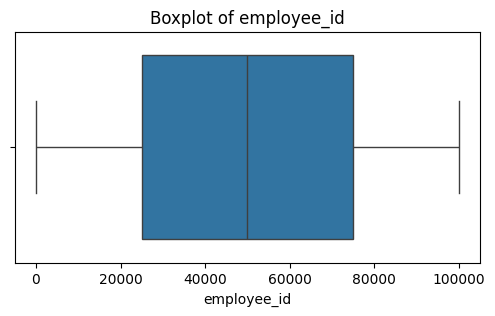

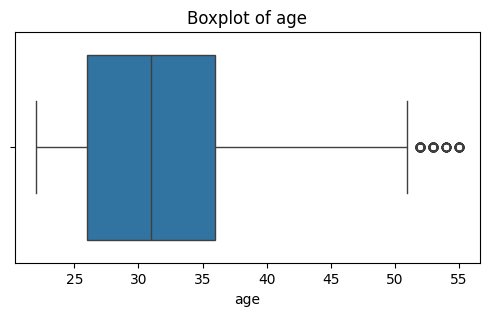

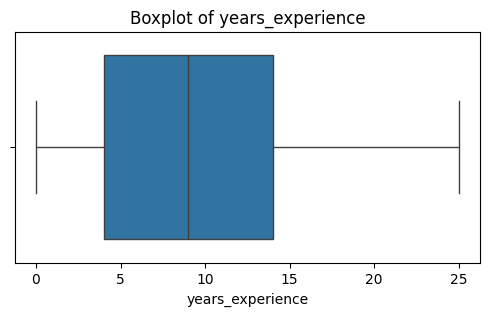

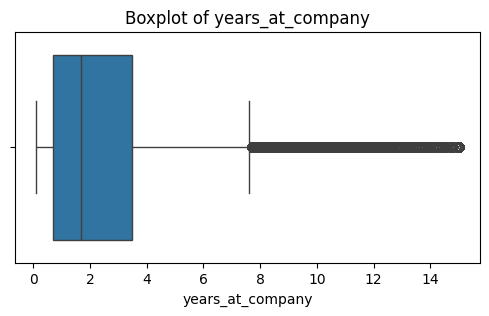

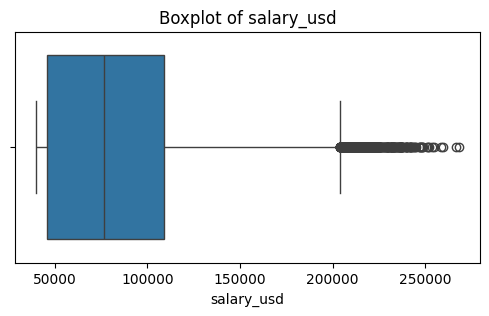

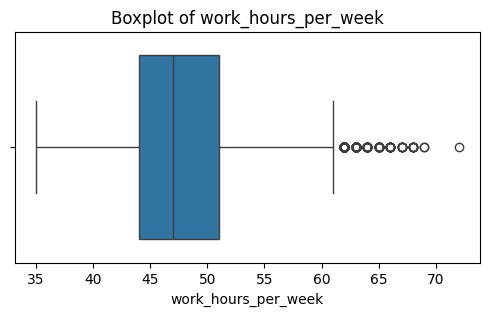

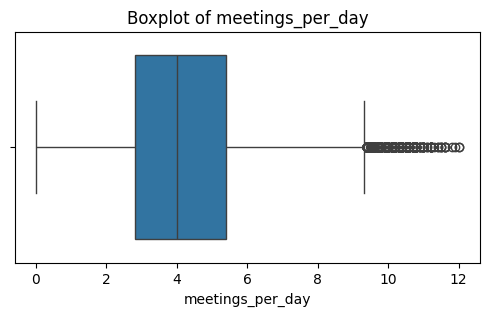

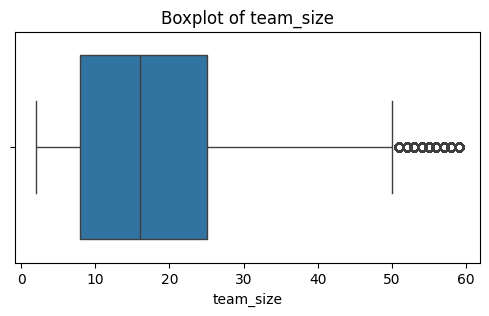

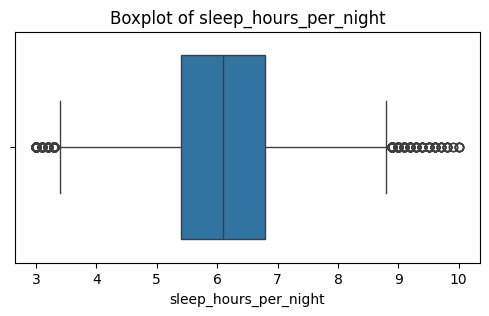

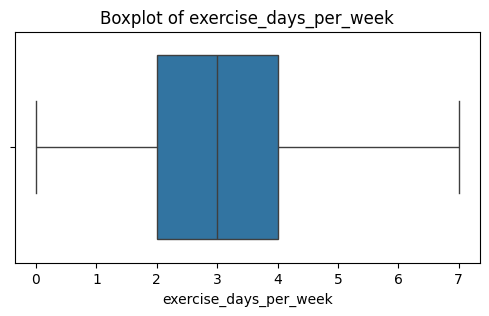

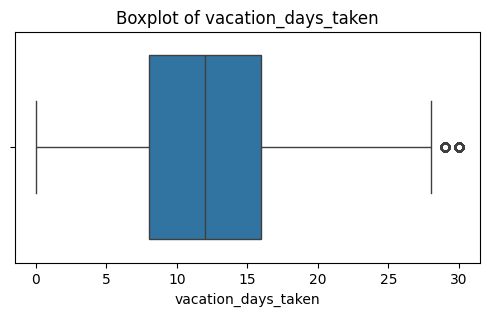

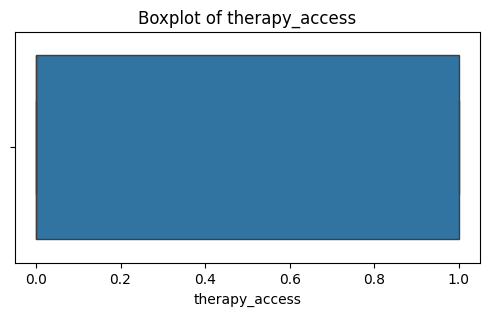

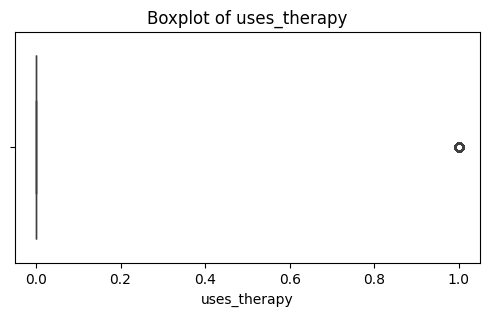

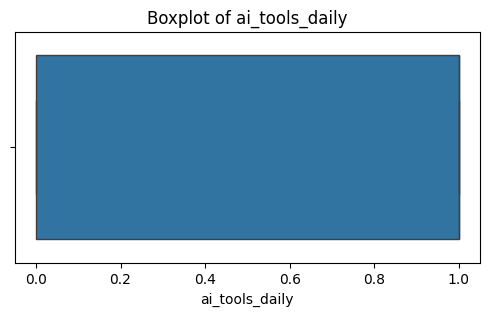

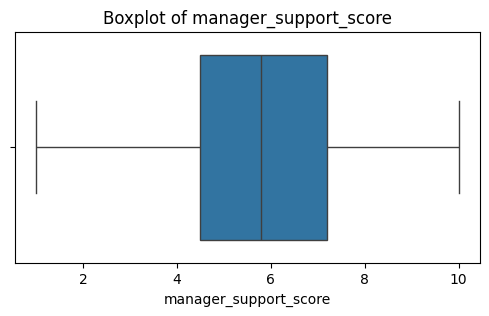

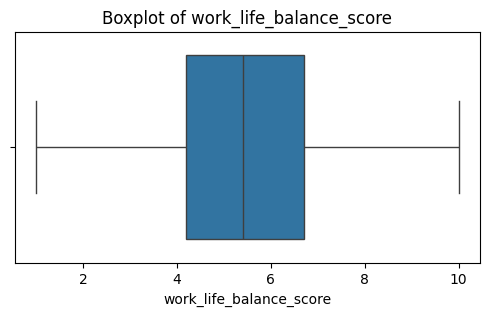

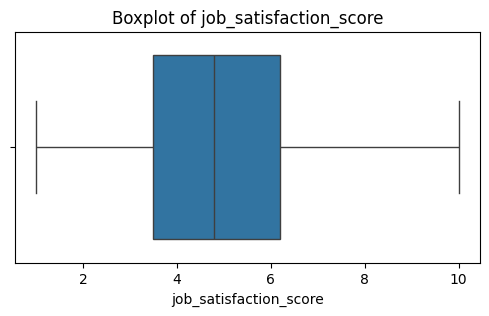

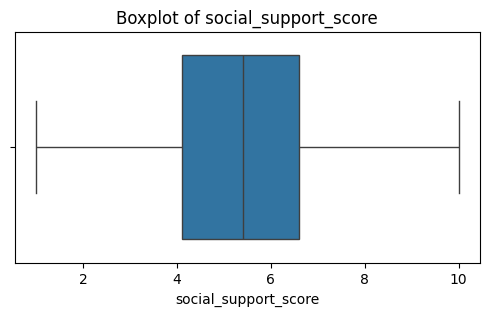

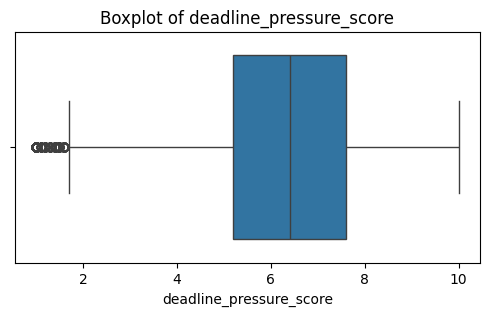

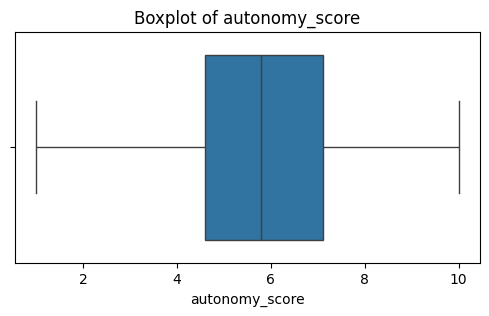

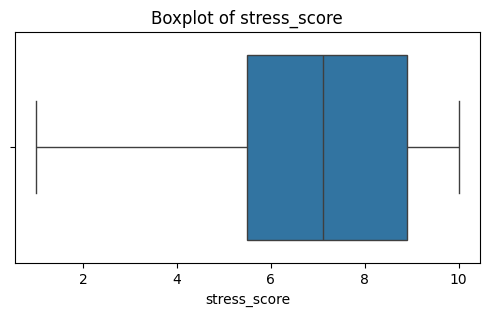

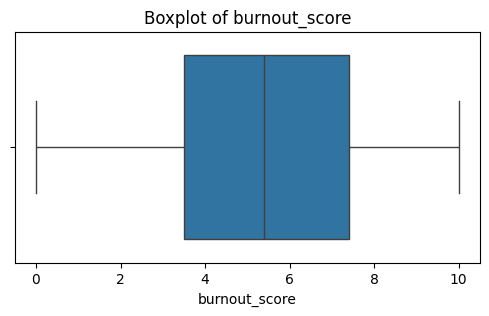

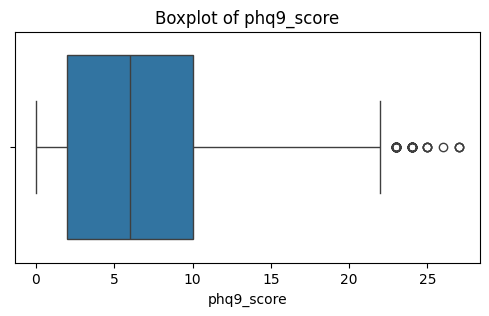

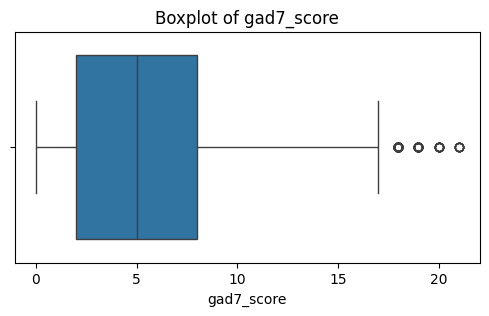

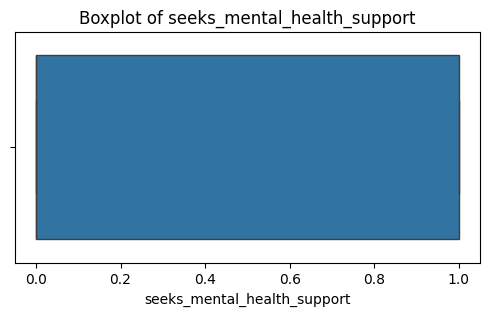

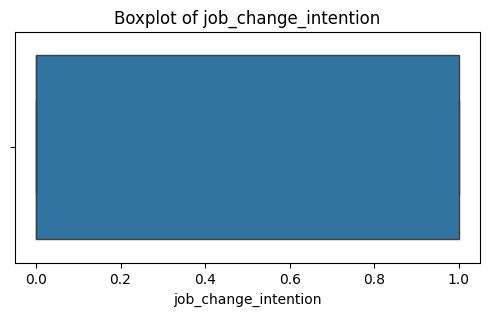

In [26]:
# Boxplot
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

# Preprocessing

In [27]:
target_column = 'burnout_level'

extra_targets = [
    # other ML targets
    'seeks_mental_health_support',
    'job_change_intention',

    # clinical scores (VERY IMPORTANT)
    'burnout_score',
    'phq9_score',
    'phq9_category',
    'gad7_score',
    'gad7_category'

]

X = df.drop(columns=[target_column] + extra_targets)
y = df[target_column]
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None)

print(f"Original dataset shape: {df.shape}")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")
print(f"Training target (y_train) shape: {y_train.shape}")
print(f"Testing target (y_test) shape: {y_test.shape}")

Original dataset shape: (100000, 36)
Training features (X_train) shape: (80000, 28)
Testing features (X_test) shape: (20000, 28)
Training target (y_train) shape: (80000,)
Testing target (y_test) shape: (20000,)


In [28]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print(f"Numerical columns identified: {list(numerical_cols)}")
print(f"Categorical columns identified: {list(categorical_cols)}")

# impute with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# impute with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_cleaned = preprocessor.fit_transform(X_train)
X_test_cleaned = preprocessor.transform(X_test)

print("\nData cleaning applied successfully.")
print(f"Shape of cleaned training data: {X_train_cleaned.shape}")
print(f"Shape of cleaned testing data: {X_test_cleaned.shape}")

# using ColumnTransformer returns numpy array, convert back to dataframe
try:
    feature_names = preprocessor.get_feature_names_out()
    X_train_cleaned_df = pd.DataFrame(X_train_cleaned, columns=feature_names, index=X_train.index)
    X_test_cleaned_df = pd.DataFrame(X_test_cleaned, columns=feature_names, index=X_test.index)
    print("\nFirst 5 rows of cleaned training data:")
    display(X_train_cleaned_df.head())
    print("\nFirst 5 rows of cleaned testing data:")
    display(X_test_cleaned_df.head())
except Exception as e:
    print(f"Could not convert cleaned data back to DataFrame for display due to: {e}")
    print("Displaying the numpy array for the first few rows of cleaned training data:")
    print(X_train_cleaned[:5])

Numerical columns identified: ['employee_id', 'age', 'years_experience', 'years_at_company', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score', 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']
Categorical columns identified: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode']

Data cleaning applied successfully.
Shape of cleaned training data: (80000, 71)
Shape of cleaned testing data: (20000, 71)

First 5 rows of cleaned training data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
47113,47114.0,35.0,14.0,1.6,94271.0,41.0,5.6,30.0,6.2,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
73319,73320.0,30.0,7.0,6.6,56728.0,47.0,4.2,8.0,5.8,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
29484,29485.0,28.0,6.0,0.1,134044.0,50.0,1.1,12.0,5.0,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
40499,40500.0,30.0,8.0,1.6,57009.0,46.0,3.4,7.0,7.3,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
73135,73136.0,38.0,18.0,10.0,55756.0,47.0,3.7,36.0,6.1,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



First 5 rows of cleaned testing data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
40848,40849.0,35.0,14.0,1.8,40000.0,39.0,2.3,7.0,6.2,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11806,11807.0,32.0,9.0,3.7,107587.0,48.0,3.8,27.0,5.3,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99645,99646.0,30.0,10.0,2.3,40000.0,42.0,2.9,16.0,5.9,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
82890,82891.0,30.0,9.0,6.8,97480.0,56.0,4.6,19.0,6.3,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
60076,60077.0,30.0,10.0,3.2,57677.0,48.0,1.9,6.0,8.0,4.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [29]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'bool']).columns

print(f"Numerical columns identified: {list(numerical_cols)}")
print(f"Categorical columns identified: {list(categorical_cols)}")

Numerical columns identified: ['employee_id', 'age', 'years_experience', 'years_at_company', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score', 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']
Categorical columns identified: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode']


In [58]:
## Outlier Removal Function helper for scenario 3 and 5

def remove_outliers(X, y, numerical_cols):

    df = X.copy()
    df["target"] = y

    mask = pd.Series(True, index=df.index)

    for col in numerical_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q1 + 1.5 * IQR

        mask &= df[col].between(lower, upper)

    df = df[mask]

    return df.drop(columns=["target"]), df["target"]

In [31]:
# impute with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# impute with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

def build_preprocessor():
    return ColumnTransformer([
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Scenario 1 (NO outlier removal)
X_train_raw = X_train
y_train_raw = y_train

def get_preprocessed_data(X_tr, X_te):
    preprocessor = build_preprocessor()
    X_tr_p = preprocessor.fit_transform(X_tr)
    X_te_p = preprocessor.transform(X_te)
    return X_tr_p, X_te_p

X_train_raw_p, X_test_p = get_preprocessed_data(X_train_raw, X_test)

print("\nData cleaning applied successfully.")
print(f"Shape of cleaned training data: {X_train_cleaned.shape}")
print(f"Shape of cleaned testing data: {X_test_cleaned.shape}")

# using ColumnTransformer returns numpy array, convert back to dataframe
try:
    feature_names = preprocessor.get_feature_names_out()
    X_train_cleaned_df = pd.DataFrame(X_train_cleaned, columns=feature_names, index=X_train.index)
    X_test_cleaned_df = pd.DataFrame(X_test_cleaned, columns=feature_names, index=X_test.index)
    print("\nFirst 5 rows of cleaned training data:")
    display(X_train_cleaned_df.head())
    print("\nFirst 5 rows of cleaned testing data:")
    display(X_test_cleaned_df.head())
except Exception as e:
    print(f"Could not convert cleaned data back to DataFrame for display due to: {e}")
    print("Displaying the numpy array for the first few rows of cleaned training data:")
    print(X_train_cleaned[:5])


Data cleaning applied successfully.
Shape of cleaned training data: (80000, 71)
Shape of cleaned testing data: (20000, 71)

First 5 rows of cleaned training data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
47113,47114.0,35.0,14.0,1.6,94271.0,41.0,5.6,30.0,6.2,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
73319,73320.0,30.0,7.0,6.6,56728.0,47.0,4.2,8.0,5.8,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
29484,29485.0,28.0,6.0,0.1,134044.0,50.0,1.1,12.0,5.0,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
40499,40500.0,30.0,8.0,1.6,57009.0,46.0,3.4,7.0,7.3,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
73135,73136.0,38.0,18.0,10.0,55756.0,47.0,3.7,36.0,6.1,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



First 5 rows of cleaned testing data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
40848,40849.0,35.0,14.0,1.8,40000.0,39.0,2.3,7.0,6.2,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11806,11807.0,32.0,9.0,3.7,107587.0,48.0,3.8,27.0,5.3,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99645,99646.0,30.0,10.0,2.3,40000.0,42.0,2.9,16.0,5.9,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
82890,82891.0,30.0,9.0,6.8,97480.0,56.0,4.6,19.0,6.3,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
60076,60077.0,30.0,10.0,3.2,57677.0,48.0,1.9,6.0,8.0,4.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [46]:
# Scenario 2 (WITH outlier removal)
X_train_out, y_train_out = remove_outliers(X_train, y_train, numerical_cols)

X_train_out_p, X_test_out_p = get_preprocessed_data(X_train_out, X_test)

print("\nOutlier applied successfully.")
print(f"Shape of training data: {X_train_out_p.shape}")
print(f"Shape of testing data: {X_test_out_p.shape}")


Outlier applied successfully.
Shape of training data: (16769, 71)
Shape of testing data: (20000, 71)


/tmp/ipykernel_6620/331129193.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, order=y_train.value_counts().index, palette='viridis', ax=axes[0])
/tmp/ipykernel_6620/331129193.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, order=y_test.value_counts().index, palette='viridis', ax=axes[1])


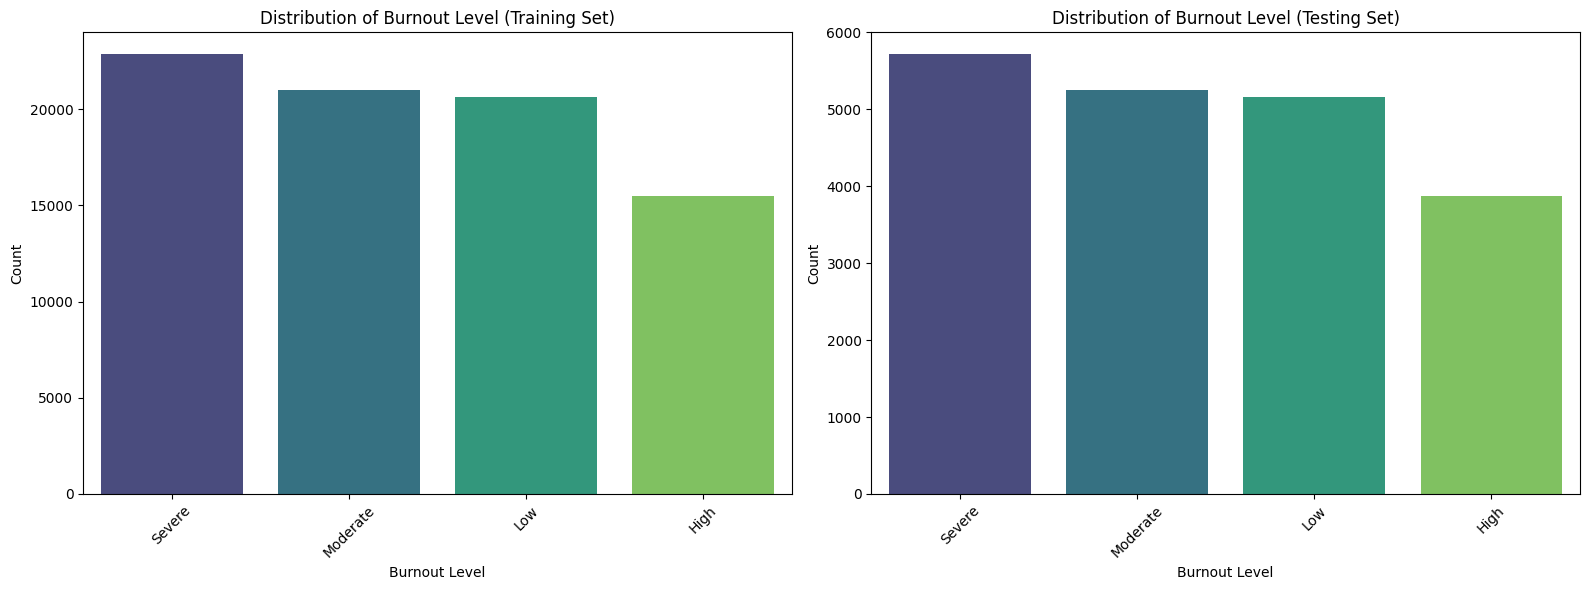

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# distribution in Training Set
sns.countplot(x=y_train, order=y_train.value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Burnout Level (Training Set)')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# distribution in Testing Set
sns.countplot(x=y_test, order=y_test.value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Burnout Level (Testing Set)')
axes[1].set_xlabel('Burnout Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [33]:
print("\nOriginal Dataset (y) Distribution:")
display(y.value_counts(normalize=False).rename('Count').to_frame().join(y.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))

print("\nTraining Set (y_train) Distribution:")
display(y_train.value_counts(normalize=False).rename('Count').to_frame().join(y_train.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))

print("\nTesting Set (y_test) Distribution:")
display(y_test.value_counts(normalize=False).rename('Count').to_frame().join(y_test.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))


Original Dataset (y) Distribution:


,Count,Percentage
burnout_level,,
Severe,28576,28.58%
Moderate,26255,26.25%
Low,25807,25.81%
High,19362,19.36%



Training Set (y_train) Distribution:


,Count,Percentage
burnout_level,,
Severe,22861,28.58%
Moderate,21004,26.25%
Low,20646,25.81%
High,15489,19.36%



Testing Set (y_test) Distribution:


,Count,Percentage
burnout_level,,
Severe,5715,28.57%
Moderate,5251,26.25%
Low,5161,25.80%
High,3873,19.36%


# Model - Random Forest

1. Scenario 1: Basic Preprocessing/Raw


===== Random Forest =====
Accuracy: 0.6785
Precision: 0.6650214691965265
Recall: 0.6785
F1-score: 0.6646832089809012

Classification Report:

              precision    recall  f1-score   support

        High       0.48      0.28      0.35      3873
         Low       0.80      0.80      0.80      5161
    Moderate       0.55      0.65      0.60      5251
      Severe       0.77      0.87      0.82      5715

    accuracy                           0.68     20000
   macro avg       0.65      0.65      0.64     20000
weighted avg       0.67      0.68      0.66     20000



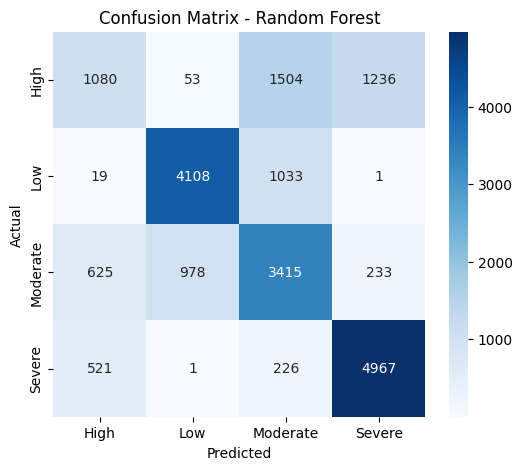

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_raw = le.fit_transform(y_train_raw)
y_test_enc = le.transform(y_test)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_cleaned, y_train_raw)

y_pred_rf = rf_model.predict(X_test_cleaned)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# 4. Evaluate using your shared function
evaluate_model(
    "Random Forest",
    y_test_enc,
    y_pred_rf,
    le.classes_
)

2. Scenario 2: Standard Scaler

In [35]:
from sklearn.preprocessing import StandardScaler

def scenario_scaler():

    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    scaler = StandardScaler(with_mean=False)

    X_train_final = scaler.fit_transform(X_tr)
    X_test_final = scaler.transform(X_te)

    return X_train_final, X_test_final, y_train_enc, y_test_enc


===== Random Forest =====
Accuracy: 0.6789
Precision: 0.6658884001831492
Recall: 0.6789
F1-score: 0.6654280173718908

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.28      0.36      3873
           1       0.80      0.80      0.80      5161
           2       0.55      0.65      0.60      5251
           3       0.77      0.87      0.82      5715

    accuracy                           0.68     20000
   macro avg       0.65      0.65      0.64     20000
weighted avg       0.67      0.68      0.67     20000



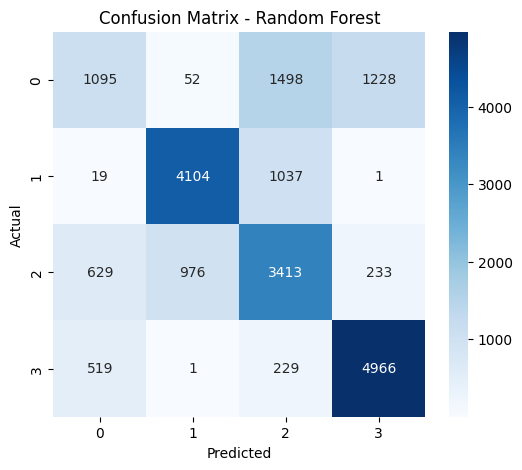

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X_train_final, X_test_final, y_train_final, y_test_final = scenario_scaler()
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_final)
y_test_enc = le.transform(y_test_final)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_final, y_train_enc)

y_pred_rf = rf_model.predict(X_test_final)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:\n")

    target_names = [str(cls) for cls in class_names]

    print(classification_report(
        y_true,
        y_pred,
        target_names=target_names
    ))

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# 4. Evaluate using your shared function
evaluate_model(
    "Random Forest",
    y_test_enc,
    y_pred_rf,
    le.classes_
)

0. High
1. Low
2. Moderate
3. Severe

3. Scenario 3: Outlier Removal

In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_out_enc = le.fit_transform(y_train_out)

In [44]:
def scenario_outlier():
    return X_train_out_p, X_test_out_p, y_train_out_enc, y_test_enc


===== Random Forest =====
Accuracy: 0.6785
Precision: 0.6650214691965265
Recall: 0.6785
F1-score: 0.6646832089809012

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.28      0.35      3873
           1       0.80      0.80      0.80      5161
           2       0.55      0.65      0.60      5251
           3       0.77      0.87      0.82      5715

    accuracy                           0.68     20000
   macro avg       0.65      0.65      0.64     20000
weighted avg       0.67      0.68      0.66     20000



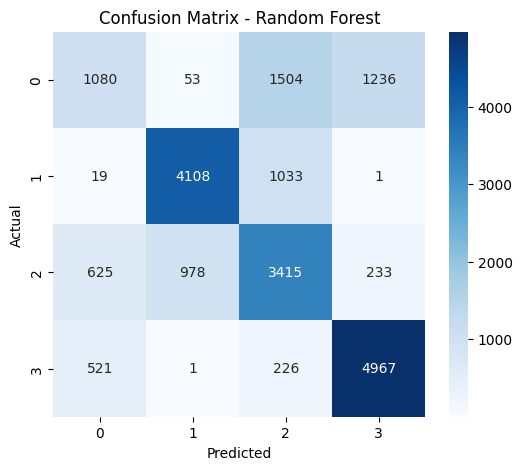

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

X_train_final, X_test_final, y_train_final, y_test_final = scenario_outlier()

le = LabelEncoder()
y_train_ecc = le.fit_transform(y_train_final)
y_test_ecc = le.transform(y_test_final)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train_cleaned, y_train_raw)

y_pred_rf = rf_model.predict(X_test_cleaned)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:\n")

    target_names = [str(cls) for cls in class_names]

    print(classification_report(
        y_true,
        y_pred,
        target_names=target_names
    ))

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# 4. Evaluate using your shared function
evaluate_model(
    "Random Forest",
    y_test_ecc,
    y_pred_rf,
    le.classes_
)

4. Scenario 4: SMOTE

In [62]:
def scenario_smote():
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    smote = SMOTE(random_state=42)

    X_train_final, y_train_final = smote.fit_resample(X_tr, y_train_enc)

    return X_train_final, X_te, y_train_final, y_test_enc


===== Random Forest =====
Accuracy: 0.6829
Precision: 0.6755071902866894
Recall: 0.6829
F1-score: 0.6778903575806782

Classification Report:

              precision    recall  f1-score   support

        High       0.49      0.39      0.43      3873
         Low       0.79      0.80      0.80      5161
    Moderate       0.57      0.61      0.59      5251
      Severe       0.80      0.84      0.82      5715

    accuracy                           0.68     20000
   macro avg       0.66      0.66      0.66     20000
weighted avg       0.68      0.68      0.68     20000



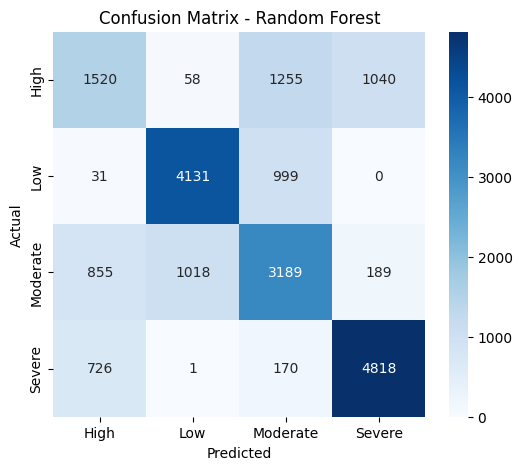

In [67]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

X_train_final, X_test_final, y_train_final, y_test_final = scenario_smote()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight=None,
)

rf_model.fit(X_train_final, y_train_final)

y_pred_rf = rf_model.predict(X_test_final)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(model_name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:\n")
    print(classification_report(
        y_true,
        y_pred,
        target_names=class_names
    ))

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# 4. Evaluate using your shared function
evaluate_model(
    "Random Forest",
    y_test_final,
    y_pred_rf,
    le.classes_
)

5. Scenario 5: Mix All Scenario

In [68]:
def scenario_mix():

    # 1. preprocess (NO change to test set)
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    # 2. scale
    scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X_tr)
    X_test_final = scaler.transform(X_te)

    df = pd.DataFrame(X_scaled)

    # 4. outlier detection (SOFT VERSION)
    outlier_count = np.zeros(len(df))

    for col in df.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count += ~df[col].between(lower, upper)

    # 5. keep rows with limited outliers (IMPORTANT FIX)
    mask = outlier_count <= 2   # <-- key change

    X_filtered = df[mask].values
    y_filtered = y_train_enc[mask.values]

    # safety check (prevents SMOTE crash)
    if len(X_filtered) < 10:
        print("Warning: too few samples after filtering. Skipping outlier step.")
        X_filtered = X_scaled
        y_filtered = y_train_enc

    # 6. SMOTE
    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_filtered, y_filtered)

    return X_train_final, X_test_final, y_train_final, y_test_enc


===== Random Forest =====
Accuracy: 0.6404
Precision: 0.6231921077638534
Recall: 0.6404
F1-score: 0.6236818159225446

Classification Report:

              precision    recall  f1-score   support

        High       0.42      0.22      0.29      3873
         Low       0.77      0.76      0.76      5161
    Moderate       0.50      0.60      0.55      5251
      Severe       0.74      0.86      0.79      5715

    accuracy                           0.64     20000
   macro avg       0.61      0.61      0.60     20000
weighted avg       0.62      0.64      0.62     20000



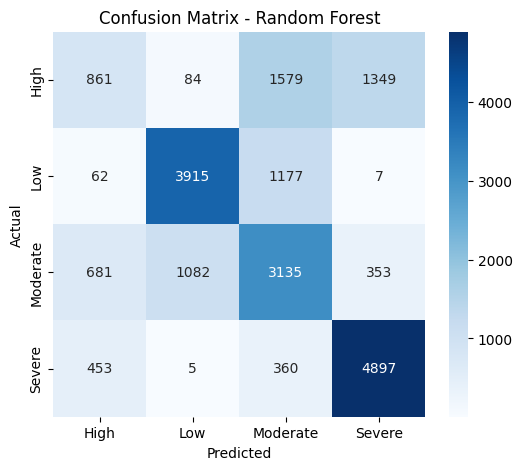

In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_ecc = le.transform(y_test)

X_train_final, X_test_final, y_train_final, y_test_final = scenario_mix()

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight=None,
)

rf_model.fit(X_train_final, y_train_final)

y_pred_rf = rf_model.predict(X_test_final)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_name, y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n===== {model_name} =====")
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-score:", f1)
    print("\nClassification Report:\n")

    target_names = [str(cls) for cls in class_names]

    print(classification_report(
        y_true,
        y_pred,
        target_names=target_names
    ))

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# 4. Evaluate using your shared function
evaluate_model(
    "Random Forest",
    y_test_ecc,
    y_pred_rf,
    le.classes_
)